In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5],
    "score": [50, 55, 65, 70, 75]
})

# 1. 독립변수(X)와 종속변수(y) 나누기
# 독립변수 X는 2차원 형태(DataFrame)여야 하므로 리스트 형태로 대괄호를 두 번 감쌉니다.
X = df[["hours"]]
y = df["score"]

# 2. 선형회귀 모델 불러오기
from sklearn.linear_model import LinearRegression

# 3. 모델 객체 생성하기
model = LinearRegression()

# 4. 모델 학습시키기
model.fit(X, y)

# 5. 학습된 모델로 예측하기
y_pred = model.predict(X)
print("기존 데이터 예측값:", y_pred)

# 6. 기울기(가중치/계수) 확인하기
# 모델 속성이므로 이름 끝에 언더스코어(_)가 붙습니다.
print("기울기(coef_):", model.coef_)

# 7. 절편(편향) 확인하기
print("절편(intercept_):", model.intercept_)

# 8. 공부시간이 6시간일 때 점수 예측하기
# 2차원 입력 형태로 [[6]]을 전달합니다.
pred = model.predict([[6]])
print("6시간 공부 시 예상 점수:", pred[0])

기존 데이터 예측값: [50.  56.5 63.  69.5 76. ]
기울기(coef_): [6.5]
절편(intercept_): 43.5
6시간 공부 시 예상 점수: 82.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 데이터프레임 생성
df = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5],
    "sleep": [6, 7, 6, 8, 7],
    "score": [50, 58, 65, 72, 78]
})

# 1. 독립변수 2개(hours, sleep)와 종속변수(score)를 나누세요
X = df[["hours", "sleep"]]
y = df["score"]

# 2. 다중회귀에 사용할 선형회귀 모델을 불러오세요
from sklearn.linear_model import LinearRegression

# 3. 모델 객체를 만드세요
model = LinearRegression()

# 4. 모델을 학습하세요
model.fit(X, y)

# 5. 학습 데이터로 예측하세요
y_pred = model.predict(X)
print("학습 데이터 예측값:", y_pred)

# 6. 각 독립변수의 회귀계수를 확인하세요
print("회귀계수 (hours, sleep 순서):", model.coef_)

# 7. 절편을 확인하세요
print("절편:", model.intercept_)

# 8. 공부시간 6시간, 수면 7시간일 때 점수를 예측하세요
pred = model.predict([[6, 7]])
print("공부 6시간, 수면 7시간일 때 예상 점수:", pred[0])

학습 데이터 예측값: [50.53684211 57.75789474 64.34736842 71.88421053 78.47368421]
회귀계수 (hours, sleep 순서): [6.90526316 0.31578947]
절편: 41.73684210526314
공부 6시간, 수면 7시간일 때 예상 점수: 85.37894736842105


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


==== 1. 데이터 확인 ====
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

[데이터 정보]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

==== 2. 수치형 데이터 요약 통계량 ====
               age          bmi 

/tmp/ipykernel_1041/3101076235.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, ax=axes[2], palette='Set2')


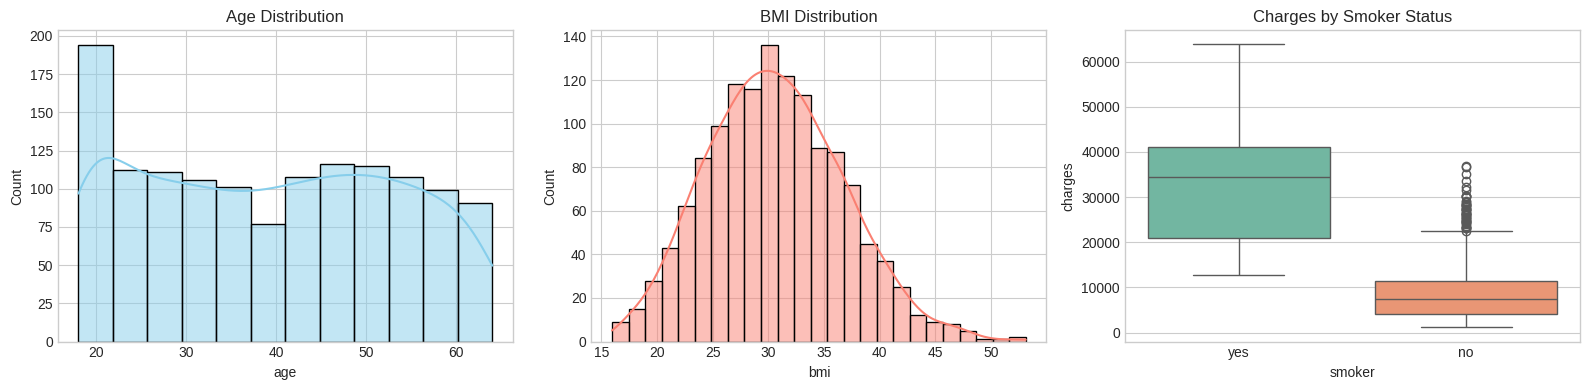


==== 3. 파생변수 및 인코딩 적용 후 데이터 ====
   age     bmi  children      charges  is_obese  obese_smoker  sex_male  \
0   19  27.900         0  16884.92400         0             0         0   
1   18  33.770         1   1725.55230         1             0         1   
2   28  33.000         3   4449.46200         1             0         1   
3   33  22.705         0  21984.47061         0             0         1   
4   32  28.880         0   3866.85520         0             0         1   

   smoker_yes  region_northwest  region_southeast  region_southwest  
0           1                 0                 0                 1  
1           0                 0                 1                 0  
2           0                 0                 1                 0  
3           0                 1                 0                 0  
4           0                 1                 0                 0  


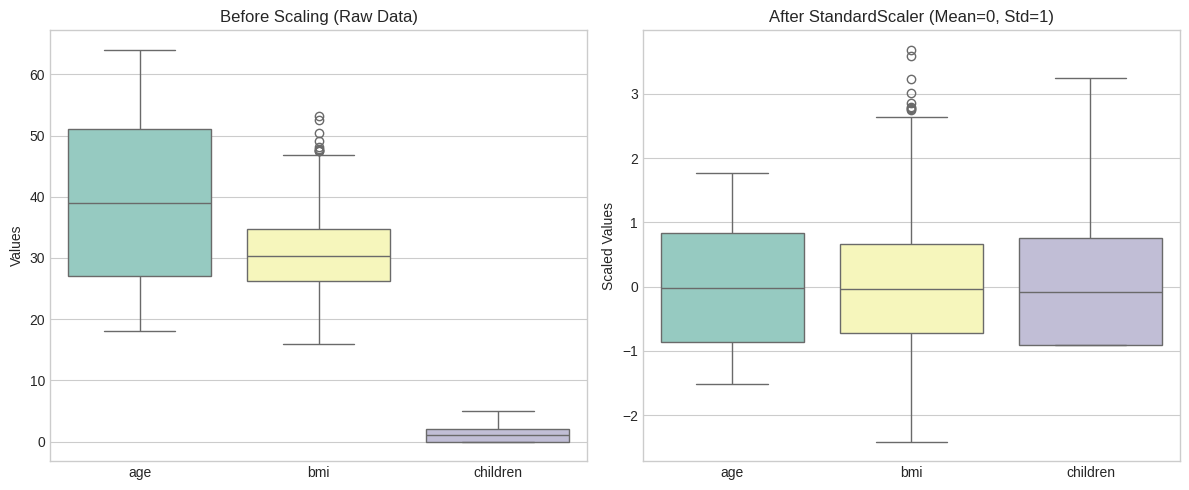


==== 4. 학습/테스트 데이터 분할 결과 ====
학습 데이터 크기 (X_train_sm): (936, 11)
테스트 데이터 크기 (X_test_sm) : (402, 11)

==== 5. 모델 평가 결과 ====
Train R² Score : 0.8605
Test R² Score  : 0.8711
Test RMSE      : $4,347.61

[주요 변수 회귀계수 (Coefficients)]
         Feature  Coefficient
    obese_smoker 19973.182965
      smoker_yes 13389.232020
           const  9642.187512
             age  3737.103360
             bmi   654.355489
        children   581.220375
region_northwest  -375.852672
        sex_male  -408.306457
        is_obese  -675.440436
region_southeast  -781.052761
region_southwest -1354.132755

==== 6. 신규 데이터 예측 결과 ====
입력 정보: 35세 | BMI 32.5 (비만) | 자녀 2명 | 여성 | 흡연자 | Southeast
예상 연간 의료 보험료: $41,062.37


In [ ]:
# ==============================================================================
# [통합 코드] 머신러닝 전체 파이프라인 (EDA -> 파생변수 -> 스케일링 -> 분할 -> 모델링 -> 예측)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm  # statsmodels 모듈 추가

# ------------------------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------------------------
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

print("==== 1. 데이터 확인 ====")
print(df.head())
print("\n[데이터 정보]")
print(df.info())


# ------------------------------------------------------------------------------
# 2. 탐색적 데이터 분석 (EDA) 시각화
# ------------------------------------------------------------------------------
print("\n==== 2. 수치형 데이터 요약 통계량 ====")
print(df.describe())

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 나이(age) 분포
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

# (2) BMI 분포
sns.histplot(df['bmi'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('BMI Distribution')

# (3) 흡연 여부에 따른 보험료(charges) 분포
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Charges by Smoker Status')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 3. 파생변수 생성 및 범주형 변수 인코딩
# ------------------------------------------------------------------------------
# 파생변수 1: BMI 30 이상을 고위험 비만(is_obese)으로 지정 (1: 비만, 0: 정상/경도)
df['is_obese'] = (df['bmi'] >= 30).astype(int)

# 파생변수 2: 고위험 교차 변수 - 비만이면서 흡연자인 경우 (obese_smoker)
df['obese_smoker'] = df['is_obese'] * (df['smoker'] == 'yes').astype(int)

# 범주형 변수 원-핫 인코딩 (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

print("\n==== 3. 파생변수 및 인코딩 적용 후 데이터 ====")
print(df_encoded.head())


# ------------------------------------------------------------------------------
# 4. 데이터 스케일링 및 스케일링 전후 박스플롯 비교
# ------------------------------------------------------------------------------
scale_cols = ['age', 'bmi', 'children']

# 스케일링 전 데이터 복사
X_before_scale = df_encoded[scale_cols].copy()

# StandardScaler 적용
scaler = StandardScaler()
X_after_scale = pd.DataFrame(
    scaler.fit_transform(X_before_scale),
    columns=scale_cols
)

# 스케일링 전/후 박스플롯 시각화 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_before_scale, ax=axes[0], palette='Set3')
axes[0].set_title('Before Scaling (Raw Data)')
axes[0].set_ylabel('Values')

sns.boxplot(data=X_after_scale, ax=axes[1], palette='Set3')
axes[1].set_title('After StandardScaler (Mean=0, Std=1)')
axes[1].set_ylabel('Scaled Values')

plt.tight_layout()
plt.show()

# 전체 데이터셋에 스케일링된 값 적용
df_encoded[scale_cols] = X_after_scale


# ------------------------------------------------------------------------------
# 5. 독립변수/종속변수 분리 및 7:3 데이터 분할
# ------------------------------------------------------------------------------
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# statsmodels 전용: 절편(const)항 추가
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant='add')

print("\n==== 4. 학습/테스트 데이터 분할 결과 ====")
print(f"학습 데이터 크기 (X_train_sm): {X_train_sm.shape}")
print(f"테스트 데이터 크기 (X_test_sm) : {X_test_sm.shape}")


# ------------------------------------------------------------------------------
# 6. statsmodels OLS 선형회귀 모델 학습 및 평가
# ------------------------------------------------------------------------------
# OLS 모델 생성 및 학습
model = sm.OLS(y_train, X_train_sm).fit()

# 상세 요약 보고서 출력 (필요 시 주석 해제)
# print(model.summary())

# 예측 수행
y_pred_train = model.predict(X_train_sm)
y_pred_test = model.predict(X_test_sm)

# 성능 지표 측정
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n==== 5. 모델 평가 결과 ====")
print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")
print(f"Test RMSE      : ${rmse:,.2f}")

print("\n[주요 변수 회귀계수 (Coefficients)]")
coef_df = pd.DataFrame({'Feature': model.params.index, 'Coefficient': model.params.values})
print(coef_df.sort_values(by='Coefficient', ascending=False).to_string(index=False))


# ------------------------------------------------------------------------------
# 7. 신규 가상 데이터 입력 및 보험료 예측
# ------------------------------------------------------------------------------
# 신규 고객 데이터 (35세, BMI 32.5 비만, 자녀 2명, 여성, 흡연함, southeast 지역)
new_customer_raw = pd.DataFrame([{
    'age': 35,
    'bmi': 32.5,
    'children': 2,
    'is_obese': 1,              # BMI >= 30 이므로 1
    'obese_smoker': 1,          # 비만이면서 흡연자이므로 1
    'sex_male': 0,              # 여성
    'smoker_yes': 1,            # 흡연자
    'region_northwest': 0,
    'region_southeast': 1,      # southeast 지역
    'region_southwest': 0
}])

# 수치형 변수 스케일링 변환 (fit_transform이 아닌 transform 사용)
new_customer_scaled = new_customer_raw.copy()
new_customer_scaled[scale_cols] = scaler.transform(new_customer_raw[scale_cols])

# statsmodels 전용: 절편(const)항 추가
new_customer_scaled_sm = sm.add_constant(new_customer_scaled, has_constant='add')

# 학습된 모델로 예측
predicted_charge = model.predict(new_customer_scaled_sm).values[0]

print("\n==== 6. 신규 데이터 예측 결과 ====")
print("입력 정보: 35세 | BMI 32.5 (비만) | 자녀 2명 | 여성 | 흡연자 | Southeast")
print(f"예상 연간 의료 보험료: ${predicted_charge:,.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 32.0 MB/s eta 0:00:00


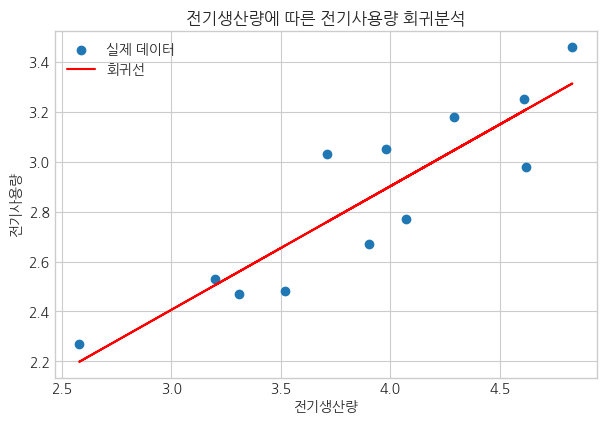

생산량이 4일 때 예측 전기사용량: 2.9020 (백만 kWh)


In [ ]:
# 1. 코랩용 한글 폰트 라이브러리 설치
!pip install -q koreanize-matplotlib

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import koreanize_matplotlib  # 한글 깨짐 자동 방지 설정

# 월별 전기생산금액(억원)
X = [3.52, 2.58, 3.31, 4.07, 4.62, 3.98, 4.29, 4.83, 3.71, 4.61, 3.90, 3.20]
# 월별 전기 사용량(백만kwh)
y = [2.48, 2.27, 2.47, 2.77, 2.98, 3.05, 3.18, 3.46, 3.03, 3.25, 2.67, 2.53]

# 선형 회귀 분석
slope, intercept, r_value, p_value, stderr = stats.linregress(X, y)

# 산점도 및 회귀선 그리기
x1 = np.array(X)
plt.figure(figsize=(7, 4.5))
plt.scatter(X, y, label='실제 데이터')
plt.plot(x1, slope * x1 + intercept, c="red", label='회귀선')
plt.xlabel("전기생산량")
plt.ylabel("전기사용량")
plt.title("전기생산량에 따른 전기사용량 회귀분석")
plt.legend()
plt.grid(True)
plt.show()

# 생산량이 4일 때 전기사용량 예측
pred_y = 4 * slope + intercept
print(f"생산량이 4일 때 예측 전기사용량: {pred_y:.4f} (백만 kWh)")

In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. house.csv 파일 불러오기
df = pd.read_csv("house.csv")
print("=== 데이터 확인 ===")
print(df.head())
print("\n" + "="*50 + "\n")

# 2. 종속변수(y)와 독립변수(X) 분리
y = df["price"]
X = df[["area", "rooms", "age"]]

# 3. 절편(상수항) 추가하기 - statsmodels 필수 절차
X = sm.add_constant(X)

# 4. OLS 회귀 모형 생성 및 학습
model = sm.OLS(y, X)
result = model.fit()

# 5. 회귀 분석 요약 결과 출력
print("=== 회귀 분석 요약 결과 ===")
print(result.summary())

1. 회귀분석(Regression)이란?

1.1. 독립변수(X)와 종속변수(Y)의 관계식을 구하는 기법
독립변수가 한단위 증가할 때 종속변수에 미치는 영향을 측정하기 위한 통계적 예측 모형

1.2. 추정 : 회귀식, 회귀계수

1.3. 검정 : 독립변수의 영향력, 모형의 적합성(R2) 등


2. 회귀분석의 종류

2.1. 단순회귀분석: 독립변수가 1개인 회귀모형
(예) 기업의 광고집행액(X)을 이용하여 그 기업의 매출액(Y)을 예측하는 모형

2.2. 중회귀분석: 독립변수가 2개 이상인 회귀모형
(예) 어린이의 연령(X1)과 하루 평균 학습시간(X2)을 이용하여 그 어린이의 성적(Y)을 예측하는 모형

3. 회귀분석 프로세스

3.1. 분석을 위한 주제 결정
  ex) 교육시간이 직원의 업무 수행에 영향을 주는가?
      식사시간이 아이의 두뇌발달에 영향을 주는가?

3.2. 독립변수와 종속변수 선정
  독립변수 : 교육시간
  종속변수 : 업무능력

3.3. 가설 설정
  귀무가설(H0) : 교육시간이 업무 능력 점수에 영향을 주지 않는다.
  대립가설(H1) : 교육시간이 업무 능력 점수에 영향을 준다.

3.4. 데이터 수집

3.5. 데이터 전처리 : 결측값 처리, 데이터 중에서 특이하거나 이상한 데이터의 제거(이상치 제거), 표준화 등

3.6. 모델을 적용하여 데이터 분석

3.7. 결과 해석
  p-value가 0.05보다 작으면 대립가설(H1) 채택
  결정계수가 0~1 사이의 값을 가지며 0.65~0.7 이상이어야 좋은 회귀모형이라고 할 수 있음

[문제 1] 데이터 로드 및 기초 탐색

1. 상위 5개 행:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

2. 요약 통계량:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

[문제 2] EDA 시각화 작성


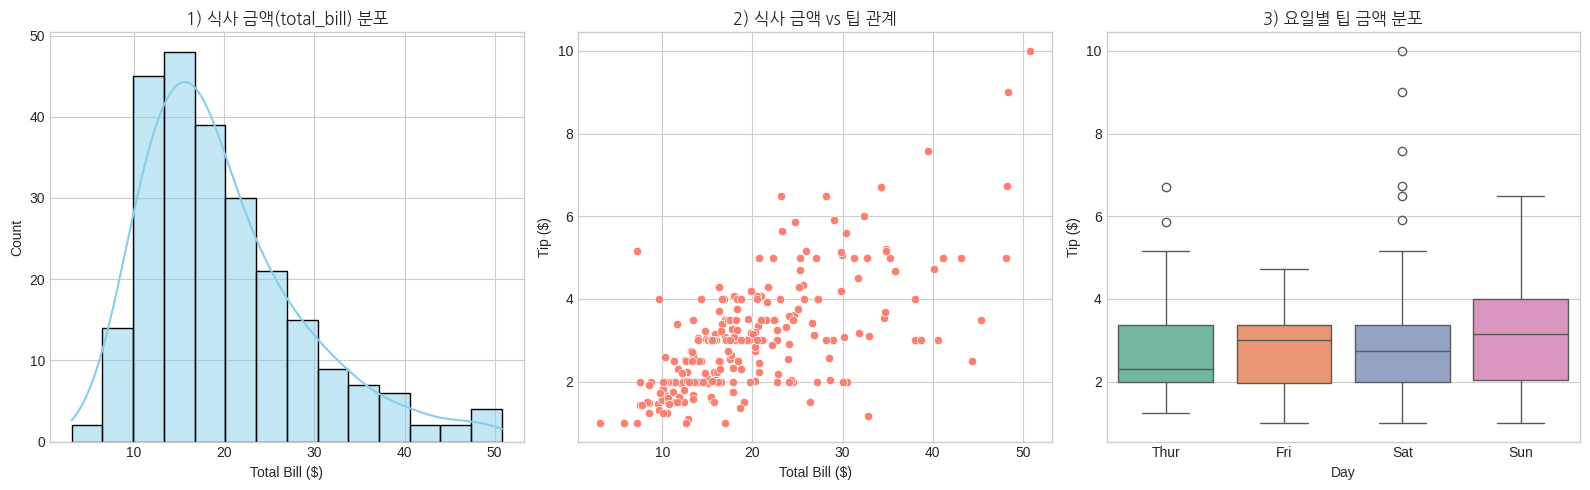


[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩

인코딩 후 데이터 상위 5개 행:
   total_bill   tip  size  price_per_person  sex_Female  smoker_No  day_Fri  \
0       16.99  1.01     2          8.495000           1          1        0   
1       10.34  1.66     3          3.446667           0          1        0   
2       21.01  3.50     3          7.003333           0          1        0   
3       23.68  3.31     2         11.840000           0          1        0   
4       24.59  3.61     4          6.147500           1          1        0   

   day_Sat  day_Sun  time_Dinner  
0        0        1            1  
1        0        1            1  
2        0        1            1  
3        0        1            1  
4        0        1            1  

[문제 4] 데이터 스케일링 및 비교 시각화


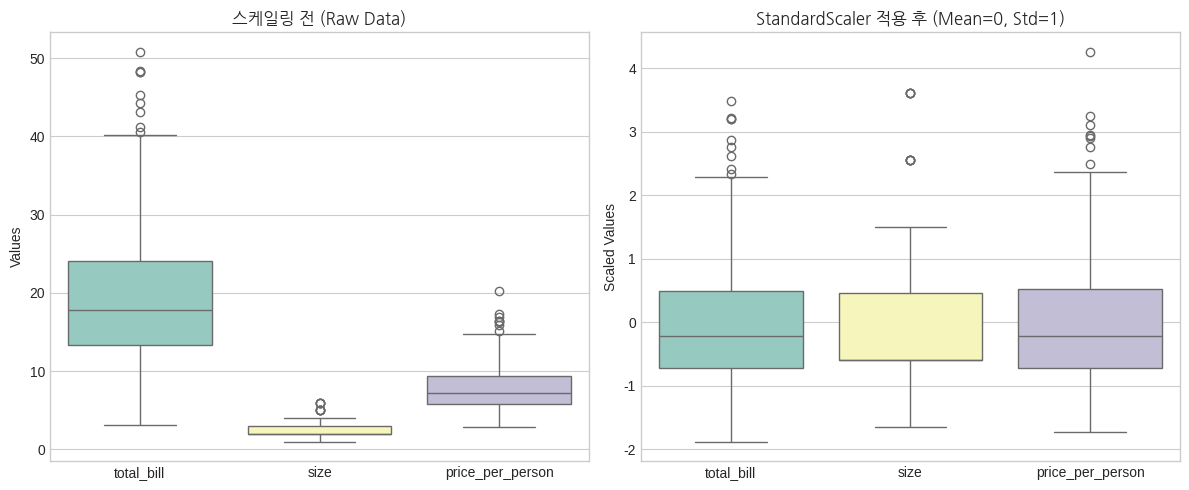


[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할
학습 데이터 크기 (X_train_sm): (170, 10)
테스트 데이터 크기 (X_test_sm) : (74, 10)

[문제 6] statsmodels OLS 모델 학습 및 성능 평가
Train R² Score : 0.4962
Test R² Score  : 0.2931
Test RMSE      : $0.9653

[주요 변수별 회귀계수 및 유의확률]
                  Coefficient  P-Value
const                  2.9666   0.0000
total_bill             1.1968   0.0004
size                   0.0046   0.9860
price_per_person      -0.2952   0.2824
sex_Female            -0.0848   0.6318
smoker_No              0.2769   0.1344
day_Fri                0.2087   0.6419
day_Sat                0.0513   0.9250
day_Sun                0.0257   0.9623
time_Dinner           -0.1599   0.7533

[문제 7] 신규 데이터 팁 금액 예측
신규 손님 정보: total_bill=$50.0 | size=4명 | Female | Non-Smoker | Sun | Dinner
-> 예상 팁(Tip) 금액: $6.63


In [ ]:
# ==============================================================================
# 1. 한글 폰트 설치 및 패키지 불러오기 (한글 깨짐 완벽 방지)
# ==============================================================================
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# ==============================================================================
# [문제 1] 데이터 로드 및 기초 탐색
# ==============================================================================
print("="*60)
print("[문제 1] 데이터 로드 및 기초 탐색")
print("="*60)

df = sns.load_dataset('tips')

print("\n1. 상위 5개 행:")
print(df.head())

print("\n2. 요약 통계량:")
print(df.describe())


# ==============================================================================
# [문제 2] 탐색적 데이터 분석(EDA) 그래프 작성 및 분석
# ==============================================================================
print("\n" + "="*60)
print("[문제 2] EDA 시각화 작성")
print("="*60)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) 식사 금액(total_bill) 히스토그램
sns.histplot(df['total_bill'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1) 식사 금액(total_bill) 분포', fontproperties=font_prop, fontsize=12)
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Count')

# 2) 식사 금액(total_bill)과 팁(tip)의 산점도
sns.scatterplot(x='total_bill', y='tip', data=df, ax=axes[1], color='salmon')
axes[1].set_title('2) 식사 금액 vs 팁 관계', fontproperties=font_prop, fontsize=12)
axes[1].set_xlabel('Total Bill ($)')
axes[1].set_ylabel('Tip ($)')

# 3) 요일(day)별 팁(tip) 금액 박스플롯 (FutureWarning 방지를 위해 hue 지정)
sns.boxplot(x='day', y='tip', hue='day', data=df, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('3) 요일별 팁 금액 분포', fontproperties=font_prop, fontsize=12)
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Tip ($)')

plt.tight_layout()
plt.show()

"""
[EDA 인사이트 요약]
1. 식사 금액(total_bill)은 오른쪽으로 긴 꼬리를 갖는 비대칭 분포를 보이며, 주로 $10~$20 구간에 집중되어 있습니다.
2. 식사 금액이 늘어날수록 팁 금액도 함께 증가하는 명확한 양(+)의 선형 관계를 확인할 수 있습니다.
3. 요일별로는 일요일(Sun)과 토요일(Sat) 등 주말의 팁 금액 중앙값 및 상위 범위가 평일(Thur, Fri)보다 다소 높게 형성되는 경향을 보입니다.
"""


# ==============================================================================
# [문제 3] 파생변수 생성 및 범주형 원-핫 인코딩
# ==============================================================================
print("\n" + "="*60)
print("[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩")
print("="*60)

# 파생변수 생성
df['price_per_person'] = df['total_bill'] / df['size']

# 원-핫 인코딩 (drop_first=True)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'], drop_first=True, dtype=int)

print("\n인코딩 후 데이터 상위 5개 행:")
print(df_encoded.head())


# ==============================================================================
# [문제 4] 데이터 스케일링 및 비교 시각화
# ==============================================================================
print("\n" + "="*60)
print("[문제 4] 데이터 스케일링 및 비교 시각화")
print("="*60)

scale_cols = ['total_bill', 'size', 'price_per_person']

# 스케일링 전 데이터 복사
X_before_scale = df_encoded[scale_cols].copy()

# StandardScaler 적용
scaler = StandardScaler()
X_after_scale = pd.DataFrame(
    scaler.fit_transform(X_before_scale),
    columns=scale_cols
)

# 박스플롯 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_before_scale, ax=axes[0], palette='Set3')
axes[0].set_title('스케일링 전 (Raw Data)', fontproperties=font_prop, fontsize=12)
axes[0].set_ylabel('Values')

sns.boxplot(data=X_after_scale, ax=axes[1], palette='Set3')
axes[1].set_title('StandardScaler 적용 후 (Mean=0, Std=1)', fontproperties=font_prop, fontsize=12)
axes[1].set_ylabel('Scaled Values')

plt.tight_layout()
plt.show()

# 스케일링 결과를 원본 데이터프레임에 반영
df_encoded[scale_cols] = X_after_scale


# ==============================================================================
# [문제 5] 데이터 분할 및 statsmodels 전용 절편(const) 추가
# ==============================================================================
print("\n" + "="*60)
print("[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할")
print("="*60)

X = df_encoded.drop(columns=['tip'])
y = df_encoded['tip']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# statsmodels 절편(const) 추가
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant='add')

print(f"학습 데이터 크기 (X_train_sm): {X_train_sm.shape}")
print(f"테스트 데이터 크기 (X_test_sm) : {X_test_sm.shape}")


# ==============================================================================
# [문제 6] statsmodels OLS 모델 학습 및 성능 평가
# R^2이 1이면 성능 가장 우수
# ==============================================================================
print("\n" + "="*60)
print("[문제 6] statsmodels OLS 모델 학습 및 성능 평가")
print("="*60)

model = sm.OLS(y_train, X_train_sm).fit()

y_pred_train = model.predict(X_train_sm)
y_pred_test = model.predict(X_test_sm)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")
print(f"Test RMSE      : ${rmse:.4f}")

coef_summary = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': model.pvalues
})
print("\n[주요 변수별 회귀계수 및 유의확률]")
print(coef_summary.round(4))


# ==============================================================================
# [문제 7] 신규 데이터 정확한 인코딩 매핑 및 팁(Tip) 예측
# ==============================================================================
print("\n" + "="*60)
print("[문제 7] 신규 데이터 팁 금액 예측")
print("="*60)

# 1. 신규 데이터 수동 인코딩 (X.columns 구조와 100% 일치하도록 구성)
# 조건: total_bill=$50.0 | size=4 | Female | Non-Smoker | Sun | Dinner
# drop_first=True 적용 기준:
# sex_Female (여성이므로 1)
# smoker_No (비흡연자이므로 1)
# day_Sun (일요일이므로 1, 나머지는 0)
# time_Dinner (저녁이므로 1)

new_guest_dict = {
    'total_bill': 50.0,
    'size': 4,
    'price_per_person': 50.0 / 4,
    'sex_Female': 1,
    'smoker_No': 1,
    'day_Fri': 0,
    'day_Sat': 0,
    'day_Sun': 1,
    'time_Dinner': 1
}

# X_train의 컬럼 순서 및 구성에 정확히 동기화
new_guest_df = pd.DataFrame([new_guest_dict])[X.columns]

# 2. 수치형 변수 스케일링
new_guest_scaled = new_guest_df.copy()
new_guest_scaled[scale_cols] = scaler.transform(new_guest_df[scale_cols])

# 3. statsmodels 전용 절편 추가 및 예측
new_guest_sm = sm.add_constant(new_guest_scaled, has_constant='add')
predicted_tip = model.predict(new_guest_sm).values[0]

print("신규 손님 정보: total_bill=$50.0 | size=4명 | Female | Non-Smoker | Sun | Dinner")
print(f"-> 예상 팁(Tip) 금액: ${predicted_tip:.2f}")

[문제 1] 데이터 로드 및 분석 제외 변수 처리

1. 상위 5개 행:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

2. 요약 통계량:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.2

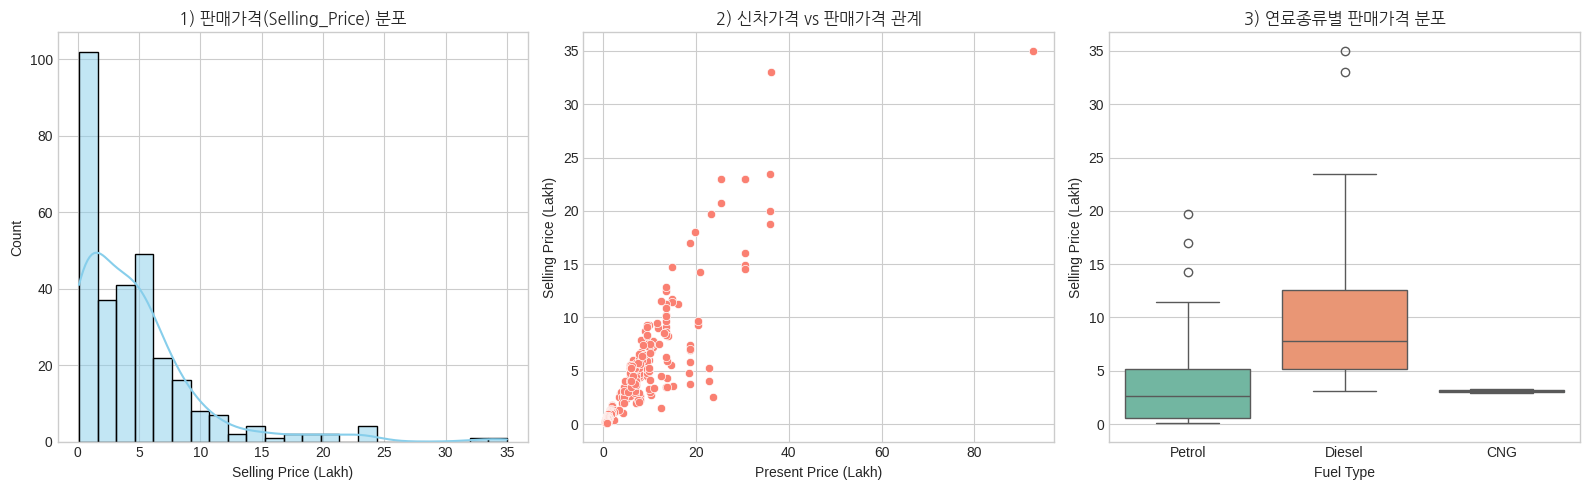


[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩

인코딩 후 데이터 상위 5개 행:
   Selling_Price  Present_Price  Kms_Driven  Owner  Vehicle_Age  \
0           3.35           5.59       27000      0           12   
1           4.75           9.54       43000      0           13   
2           7.25           9.85        6900      0            9   
3           2.85           4.15        5200      0           15   
4           4.60           6.87       42450      0           12   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0                 0                 1                       0   
1                 1                 0                       0   
2                 0                 1                       0   
3                 0                 1                       0   
4                 1                 0                       0   

   Transmission_Manual  
0                    1  
1                    1  
2                    1  
3                    1  
4                    1  

인코딩 후

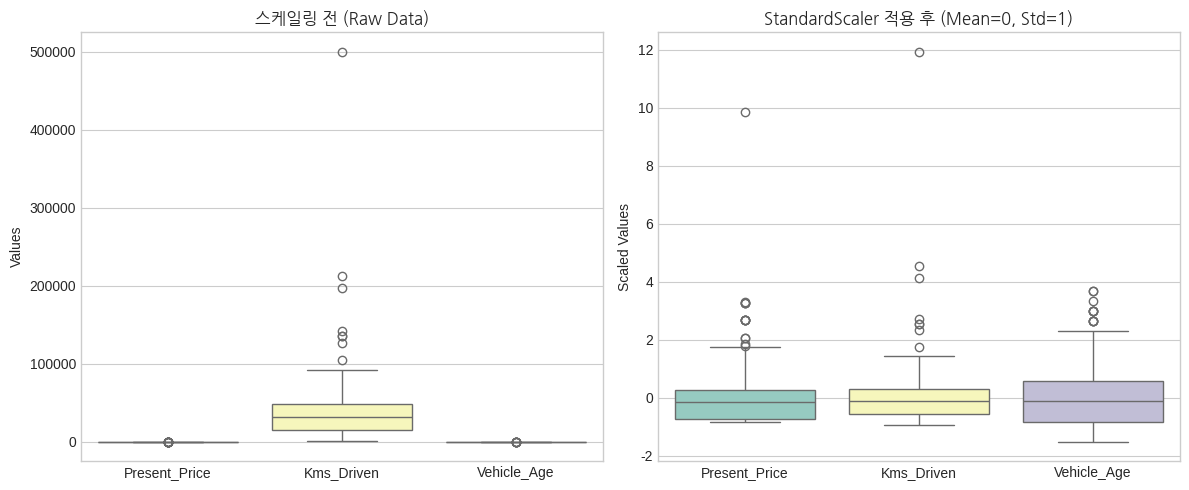


[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할
학습 데이터 크기 (X_train_sm): (210, 9)
테스트 데이터 크기 (X_test_sm) : (91, 9)

[문제 6] statsmodels OLS 모델 학습 및 성능 평가
Train R² Score : 0.8828
Test R² Score  : 0.8756
Test RMSE      : 1.8820 Lakh
Test MAPE      : 100.09 %

[주요 변수별 회귀계수 및 유의확률]
                        Coefficient  P-Value
const                        5.2936   0.0001
Present_Price                3.5986   0.0000
Kms_Driven                  -0.1723   0.1907
Owner                       -1.0303   0.0203
Vehicle_Age                 -1.0272   0.0000
Fuel_Type_Diesel             2.7118   0.0338
Fuel_Type_Petrol             0.7174   0.5636
Seller_Type_Individual      -1.1521   0.0001
Transmission_Manual         -1.4384   0.0006

[문제 7] 신규 데이터 판매가격 예측
신규 중고차 정보: 2018년식 | 신차가격 10.0 Lakh | 30,000km | Petrol | Dealer | Manual
-> 예상 판매 가격: 7.15 Lakh


'\n[최종 모델 리포트]\n1. 최종 선정 모델: 다중 선형회귀(statsmodels OLS), 독립변수 8개 + 절편\n2. 모델 성능: Test R² = 0.8756 (판매가격 변동의 약 87.6% 설명), Test RMSE = 1.8820 Lakh\n3. MAPE = 100.09%로 산출되었으나, 이는 MAPE가 오차를 실제값으로 나누는 지표 특성상\n   판매가격이 0.1~0.5 Lakh인 저가 차량에서 오차율이 급격히 커진 결과입니다.\n   따라서 본 데이터에서는 RMSE(1.88 Lakh)를 주 평가지표로 해석하는 것이 타당합니다.\n4. 유의한 변수(p<0.05): Present_Price(+3.599), Vehicle_Age(-1.027), Transmission_Manual(-1.438),\n   Seller_Type_Individual(-1.152), Owner(-1.030), Fuel_Type_Diesel(+2.712)\n   -> 신차가격이 높을수록 판매가가 상승하고, 연식이 오래되거나 수동변속기·개인판매·\n      소유이력이 많을수록 판매가가 하락하는 것으로 확인되었습니다.\n5. 신규 중고차 예측 결과: 7.15 Lakh (신차가격 10.0 Lakh 대비 약 71.5% 수준)\n'

In [ ]:
# ==============================================================================
# 1. 한글 폰트 설치 및 패키지 불러오기 (한글 깨짐 완벽 방지)
# ==============================================================================
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import statsmodels.api as sm

# ==============================================================================
# [문제 1] 데이터 로드 및 분석 제외 변수 처리
# ==============================================================================
print("="*60)
print("[문제 1] 데이터 로드 및 분석 제외 변수 처리")
print("="*60)

url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/car%20data.csv"
df = pd.read_csv(url)

print("\n1. 상위 5개 행:")
print(df.head())

print("\n2. 요약 통계량:")
print(df.describe())

# 분석 대상이 아닌 Car_Name(자동차 모델명) 컬럼 제거
df = df.drop(columns=['Car_Name'])

print("\n3. Car_Name 제거 후 컬럼:", df.columns.tolist())


# ==============================================================================
# [문제 2] 탐색적 데이터 분석(EDA) 시각화 및 인사이트 작성
# ==============================================================================
print("\n" + "="*60)
print("[문제 2] EDA 시각화 작성")
print("="*60)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Target 변수(Selling_Price) 히스토그램
sns.histplot(df['Selling_Price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1) 판매가격(Selling_Price) 분포', fontproperties=font_prop, fontsize=12)
axes[0].set_xlabel('Selling Price (Lakh)')
axes[0].set_ylabel('Count')

# 2) 신차가격(Present_Price)과 판매가격(Selling_Price) 산점도
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df, ax=axes[1], color='salmon')
axes[1].set_title('2) 신차가격 vs 판매가격 관계', fontproperties=font_prop, fontsize=12)
axes[1].set_xlabel('Present Price (Lakh)')
axes[1].set_ylabel('Selling Price (Lakh)')

# 3) 연료종류(Fuel_Type)별 판매가격 박스플롯 (FutureWarning 방지를 위해 hue 지정)
sns.boxplot(x='Fuel_Type', y='Selling_Price', hue='Fuel_Type', data=df, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('3) 연료종류별 판매가격 분포', fontproperties=font_prop, fontsize=12)
axes[2].set_xlabel('Fuel Type')
axes[2].set_ylabel('Selling Price (Lakh)')

plt.tight_layout()
plt.show()

"""
[EDA 인사이트 요약]
1. 판매가격(Selling_Price)은 오른쪽으로 긴 꼬리를 갖는 비대칭 분포(왜도 2.49)로, 대부분 0~10 Lakh 구간에 집중되어 있으며 평균(4.66)이 중앙값(3.60)보다 높게 형성되어 있습니다.
2. 신차가격이 높아질수록 판매가격도 함께 증가하는 강한 양(+)의 선형관계(상관계수 0.879)를 보이며, 다만 금액대가 높아질수록 점들의 퍼짐이 커지는 경향이 관찰됩니다.
3. 연료종류별로는 Diesel 차량의 판매가격 중앙값(6.95)이 Petrol(2.90)보다 2배 이상 높게 형성되나, CNG는 표본이 2건에 불과하여 해석에 주의가 필요합니다.
"""


# ==============================================================================
# [문제 3] 파생변수 생성 및 범주형 원-핫 인코딩
# ==============================================================================
print("\n" + "="*60)
print("[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩")
print("="*60)

# 파생변수 생성: 차량 경과 연수
df['Vehicle_Age'] = 2026 - df['Year']

# Year는 Vehicle_Age와 완전 종속(상관계수 -1)이므로 제거
df = df.drop(columns=['Year'])

# 원-핫 인코딩 (drop_first=True)
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'],
                            drop_first=True, dtype=int)

print("\n인코딩 후 데이터 상위 5개 행:")
print(df_encoded.head())
print("\n인코딩 후 컬럼:", df_encoded.columns.tolist())


# ==============================================================================
# [문제 4] 데이터 스케일링 및 비교 시각화
# ==============================================================================
print("\n" + "="*60)
print("[문제 4] 데이터 스케일링 및 비교 시각화")
print("="*60)

scale_cols = ['Present_Price', 'Kms_Driven', 'Vehicle_Age']

# 스케일링 전 데이터 복사
X_before_scale = df_encoded[scale_cols].copy()

# StandardScaler 적용
scaler = StandardScaler()
X_after_scale = pd.DataFrame(
    scaler.fit_transform(X_before_scale),
    columns=scale_cols,
    index=df_encoded.index
)

# 박스플롯 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_before_scale, ax=axes[0], palette='Set3')
axes[0].set_title('스케일링 전 (Raw Data)', fontproperties=font_prop, fontsize=12)
axes[0].set_ylabel('Values')

sns.boxplot(data=X_after_scale, ax=axes[1], palette='Set3')
axes[1].set_title('StandardScaler 적용 후 (Mean=0, Std=1)', fontproperties=font_prop, fontsize=12)
axes[1].set_ylabel('Scaled Values')

plt.tight_layout()
plt.show()

# 스케일링 결과를 원본 데이터프레임에 반영
df_encoded[scale_cols] = X_after_scale


# ==============================================================================
# [문제 5] 데이터 분할 및 statsmodels 전용 절편(const) 추가
# ==============================================================================
print("\n" + "="*60)
print("[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할")
print("="*60)

X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# statsmodels 절편(const) 추가
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant='add')

print(f"학습 데이터 크기 (X_train_sm): {X_train_sm.shape}")
print(f"테스트 데이터 크기 (X_test_sm) : {X_test_sm.shape}")


# ==============================================================================
# [문제 6] statsmodels OLS 모델 학습 및 성능 평가
# ==============================================================================
print("\n" + "="*60)
print("[문제 6] statsmodels OLS 모델 학습 및 성능 평가")
print("="*60)

model = sm.OLS(y_train, X_train_sm).fit()

y_pred_train = model.predict(X_train_sm)
y_pred_test = model.predict(X_test_sm)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")
print(f"Test RMSE      : {rmse:.4f} Lakh")
print(f"Test MAPE      : {mape:.2f} %")

coef_summary = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': model.pvalues
})
print("\n[주요 변수별 회귀계수 및 유의확률]")
print(coef_summary.round(4))


# ==============================================================================
# [문제 7] 신규 데이터 정확한 인코딩 매핑 및 판매가격 예측
# ==============================================================================
print("\n" + "="*60)
print("[문제 7] 신규 데이터 판매가격 예측")
print("="*60)

# 1. 신규 데이터 수동 인코딩 (X.columns 구조와 100% 일치하도록 구성)
# 조건: 2018년식 | Present_Price=10.0 | Kms_Driven=30000 | Petrol | Dealer | Manual
# drop_first=True 적용 기준:
# Fuel_Type_Petrol (Petrol이므로 1, 기준범주는 CNG)
# Seller_Type_Individual (Dealer이므로 0)
# Transmission_Manual (Manual이므로 1, 기준범주는 Automatic)

new_car_dict = {
    'Present_Price': 10.0,
    'Kms_Driven': 30000,
    'Owner': 0,
    'Vehicle_Age': 2026 - 2018,
    'Fuel_Type_Diesel': 0,
    'Fuel_Type_Petrol': 1,
    'Seller_Type_Individual': 0,
    'Transmission_Manual': 1
}

# X_train의 컬럼 순서 및 구성에 정확히 동기화
new_car_df = pd.DataFrame([new_car_dict])[X.columns]

# 2. 수치형 변수 스케일링
new_car_scaled = new_car_df.copy()
new_car_scaled[scale_cols] = scaler.transform(new_car_df[scale_cols])

# 3. statsmodels 전용 절편 추가 및 예측
new_car_sm = sm.add_constant(new_car_scaled, has_constant='add')
predicted_price = model.predict(new_car_sm).values[0]

print("신규 중고차 정보: 2018년식 | 신차가격 10.0 Lakh | 30,000km | Petrol | Dealer | Manual")
print(f"-> 예상 판매 가격: {predicted_price:.2f} Lakh")

"""
[최종 모델 리포트]
1. 최종 선정 모델: 다중 선형회귀(statsmodels OLS), 독립변수 8개 + 절편
2. 모델 성능: Test R² = 0.8756 (판매가격 변동의 약 87.6% 설명), Test RMSE = 1.8820 Lakh
3. MAPE = 100.09%로 산출되었으나, 이는 MAPE가 오차를 실제값으로 나누는 지표 특성상
   판매가격이 0.1~0.5 Lakh인 저가 차량에서 오차율이 급격히 커진 결과입니다.
   따라서 본 데이터에서는 RMSE(1.88 Lakh)를 주 평가지표로 해석하는 것이 타당합니다.
4. 유의한 변수(p<0.05): Present_Price(+3.599), Vehicle_Age(-1.027), Transmission_Manual(-1.438),
   Seller_Type_Individual(-1.152), Owner(-1.030), Fuel_Type_Diesel(+2.712)
   -> 신차가격이 높을수록 판매가가 상승하고, 연식이 오래되거나 수동변속기·개인판매·
      소유이력이 많을수록 판매가가 하락하는 것으로 확인되었습니다.
5. 신규 중고차 예측 결과: 7.15 Lakh (신차가격 10.0 Lakh 대비 약 71.5% 수준)
"""